In [1]:
# AI Investment Opportunity Analyzer
# Notebook 05: Explainability

import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Project paths
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
MODELS_PATH = PROJECT_ROOT / "models"
REPORTS_PATH = PROJECT_ROOT / "reports"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

# Load data and model
X_train = pd.read_csv(PROCESSED_DATA_PATH / "X_train_processed.csv")
X_test = pd.read_csv(PROCESSED_DATA_PATH / "X_test_processed.csv")
y_test = pd.read_csv(PROCESSED_DATA_PATH / "y_test.csv").squeeze()

best_model = joblib.load(MODELS_PATH / "best_model.pkl")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Model:", type(best_model).__name__)

X_train: (4000, 56)
X_test: (1000, 56)
Model: Ridge


In [2]:
# Extract feature importance from Ridge Regression coefficients

coefficients = best_model.coef_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": coefficients
})

feature_importance["absolute_importance"] = feature_importance["coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="absolute_importance",
    ascending=False
)

feature_importance.head(20)

,feature,coefficient,absolute_importance
53,competition_level_High,-19.764113,19.764113
54,competition_level_Low,17.091466,17.091466
33,market_attractiveness_score,4.681422,4.681422
34,financial_strength_score,4.186905,4.186905
3,expected_roi_percent,3.862650,3.862650
5,payback_period_years,-3.455074,3.455074
25,strategic_impact_score,3.199893,3.199893
4,irr_percent,3.159527,3.159527
7,profit_margin_percent,3.120191,3.120191
19,overall_risk_score,-2.678112,2.678112


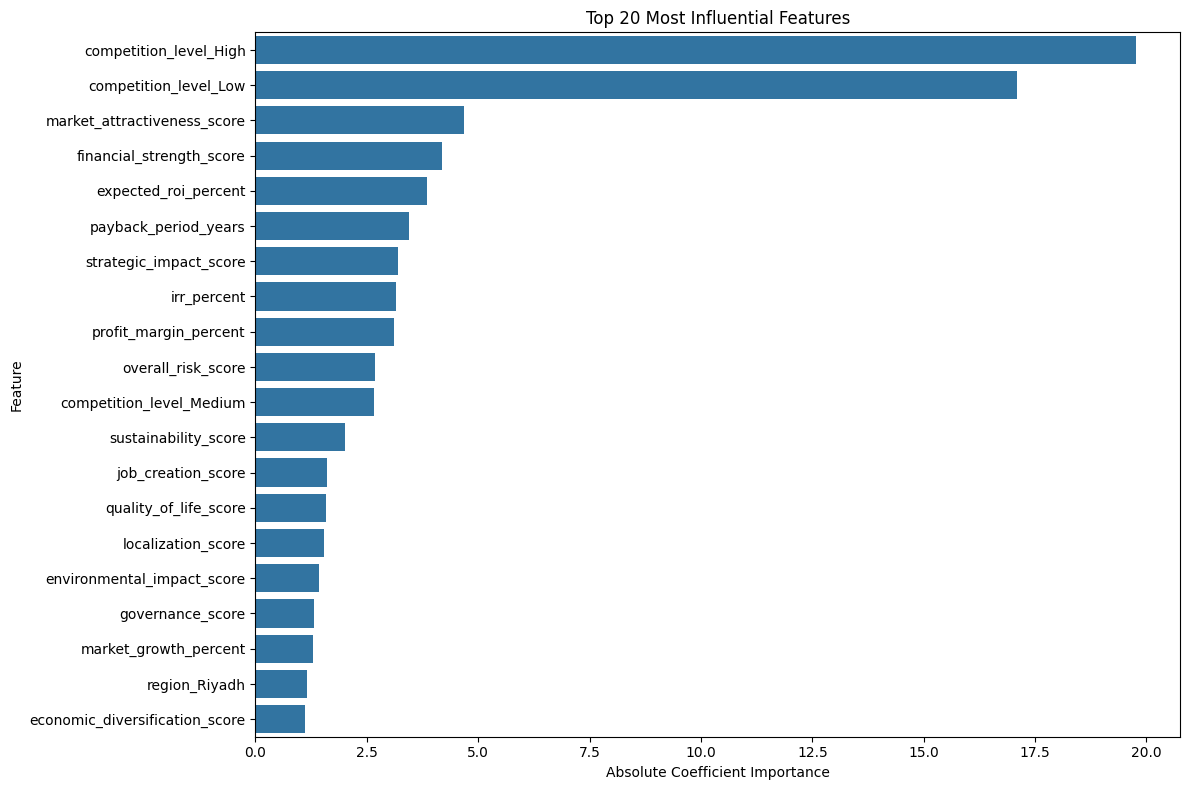

In [3]:
# Plot top 20 most important features

top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_features,
    x="absolute_importance",
    y="feature"
)

plt.title("Top 20 Most Influential Features")
plt.xlabel("Absolute Coefficient Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "top_20_feature_importance.png", dpi=300)
plt.show()

In [4]:
# Positive and negative drivers

positive_drivers = (
    feature_importance[feature_importance["coefficient"] > 0]
    .sort_values(by="coefficient", ascending=False)
    .head(10)
)

negative_drivers = (
    feature_importance[feature_importance["coefficient"] < 0]
    .sort_values(by="coefficient", ascending=True)
    .head(10)
)

print("Top positive drivers:")
display(positive_drivers)

print("Top negative drivers:")
display(negative_drivers)

Top positive drivers:


,feature,coefficient,absolute_importance
54,competition_level_Low,17.091466,17.091466
33,market_attractiveness_score,4.681422,4.681422
34,financial_strength_score,4.186905,4.186905
3,expected_roi_percent,3.862650,3.862650
25,strategic_impact_score,3.199893,3.199893
4,irr_percent,3.159527,3.159527
7,profit_margin_percent,3.120191,3.120191
55,competition_level_Medium,2.672647,2.672647
29,sustainability_score,2.011535,2.011535
22,job_creation_score,1.603916,1.603916


Top negative drivers:


,feature,coefficient,absolute_importance
53,competition_level_High,-19.764113,19.764113
5,payback_period_years,-3.455074,3.455074
19,overall_risk_score,-2.678112,2.678112
15,regulatory_risk_score,-1.084595,1.084595
18,dependency_risk_score,-1.071229,1.071229
17,market_risk_score,-1.034980,1.034980
14,financial_risk_score,-1.013849,1.013849
16,execution_risk_score,-0.954877,0.954877
38,sector_Infrastructure,-0.846679,0.846679
36,sector_Entertainment,-0.814180,0.814180


In [5]:
# Save feature importance

feature_importance_file = REPORTS_PATH / "feature_importance.csv"
feature_importance.to_csv(feature_importance_file, index=False)

print(f"Feature importance saved to: {feature_importance_file}")

Feature importance saved to: d:\Senior last\ML\ai-investment-opportunity-analyzer\reports\feature_importance.csv


In [6]:
# Local explanation using linear model contributions

def explain_prediction(row, model, top_n=5):
    """
    Explains a single prediction from a linear model by calculating
    feature contribution = feature value * coefficient.
    """
    
    coefficients = model.coef_
    
    contributions = pd.DataFrame({
        "feature": row.index,
        "value": row.values,
        "coefficient": coefficients,
        "contribution": row.values * coefficients
    })
    
    contributions["absolute_contribution"] = contributions["contribution"].abs()
    
    contributions = contributions.sort_values(
        by="absolute_contribution",
        ascending=False
    )
    
    top_contributions = contributions.head(top_n)
    
    return top_contributions

In [7]:
# Explain one test prediction

sample_index = 0

sample_row = X_test.iloc[sample_index]
sample_actual = y_test.iloc[sample_index]
sample_prediction = best_model.predict(sample_row.to_frame().T)[0]
sample_prediction = np.clip(sample_prediction, 0, 100)

print("Actual score:", round(sample_actual, 2))
print("Predicted score:", round(sample_prediction, 2))

local_explanation = explain_prediction(
    row=sample_row,
    model=best_model,
    top_n=10
)

local_explanation

Actual score: 38.1
Predicted score: 39.1


,feature,value,coefficient,contribution,absolute_contribution
19,overall_risk_score,1.153763,-2.678112,-3.089907,3.089907
5,payback_period_years,-0.838629,-3.455074,2.897525,2.897525
55,competition_level_Medium,1.000000,2.672647,2.672647,2.672647
1,capex_million,2.867576,0.836482,2.398675,2.398675
3,expected_roi_percent,-0.479367,3.862650,-1.851626,1.851626
29,sustainability_score,-0.844693,2.011535,-1.699128,1.699128
22,job_creation_score,-1.015677,1.603916,-1.629061,1.629061
4,irr_percent,-0.513357,3.159527,-1.621964,1.621964
33,market_attractiveness_score,-0.336906,4.681422,-1.577200,1.577200
2,opex_million,2.828049,-0.543021,-1.535690,1.535690


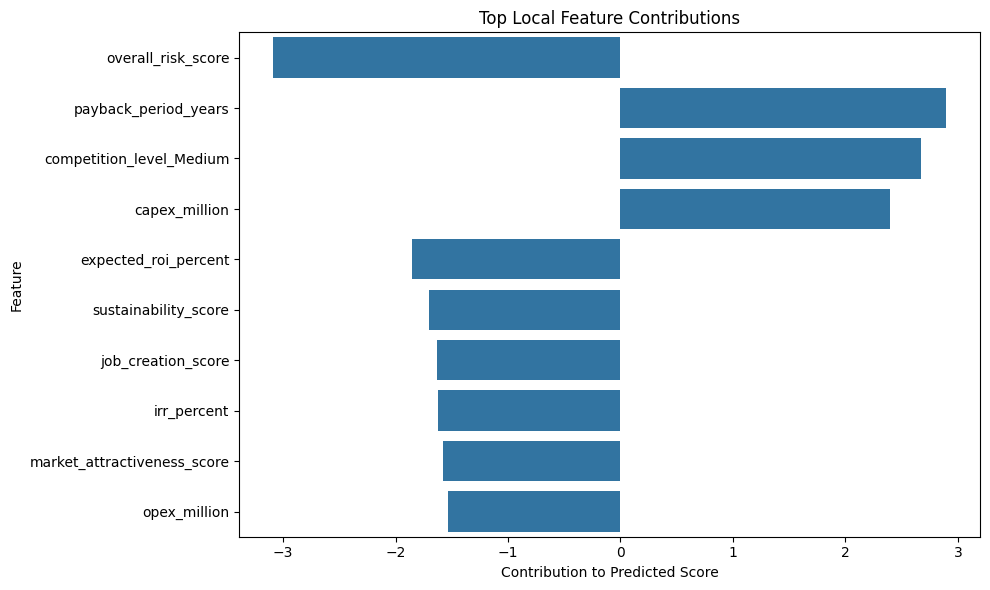

In [8]:
# Plot local explanation

plt.figure(figsize=(10, 6))
sns.barplot(
    data=local_explanation,
    x="contribution",
    y="feature"
)

plt.title("Top Local Feature Contributions")
plt.xlabel("Contribution to Predicted Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "local_explanation_example.png", dpi=300)
plt.show()

In [9]:
# Recommendation function

def assign_recommendation_from_score(score):
    if score >= 75:
        return "Invest"
    elif score >= 45:
        return "Review"
    else:
        return "Reject"


sample_recommendation = assign_recommendation_from_score(sample_prediction)

print("Predicted Score:", round(sample_prediction, 2))
print("Recommendation:", sample_recommendation)

Predicted Score: 39.1
Recommendation: Reject


In [12]:
# Improved human-readable explanation

def clean_feature_name(feature):
    return feature.replace("_", " ")


def generate_reason_text(local_explanation):
    positive_reasons = []
    negative_reasons = []
    
    for _, row in local_explanation.iterrows():
        feature = row["feature"]
        contribution = row["contribution"]
        clean_feature = clean_feature_name(feature)
        
        if contribution > 0:
            positive_reasons.append(
                f"{clean_feature} contributed positively to the predicted investment score."
            )
        else:
            negative_reasons.append(
                f"{clean_feature} contributed negatively to the predicted investment score."
            )
    
    return positive_reasons, negative_reasons


positive_reasons, negative_reasons = generate_reason_text(local_explanation)

print("Positive reasons:")
for reason in positive_reasons[:5]:
    print("-", reason)

print("\nNegative reasons:")
for reason in negative_reasons[:5]:
    print("-", reason)

Positive reasons:
- payback period years contributed positively to the predicted investment score.
- competition level Medium contributed positively to the predicted investment score.
- capex million contributed positively to the predicted investment score.

Negative reasons:
- overall risk score contributed negatively to the predicted investment score.
- expected roi percent contributed negatively to the predicted investment score.
- sustainability score contributed negatively to the predicted investment score.
- job creation score contributed negatively to the predicted investment score.
- irr percent contributed negatively to the predicted investment score.


In [13]:
# Save local explanation example

local_explanation_file = REPORTS_PATH / "local_explanation_example.csv"
local_explanation.to_csv(local_explanation_file, index=False)

print(f"Local explanation example saved to: {local_explanation_file}")

Local explanation example saved to: d:\Senior last\ML\ai-investment-opportunity-analyzer\reports\local_explanation_example.csv
